# Bathroom Humidity Analysis

**Background**

I noticed mould forming in my bathroom and wanted to understand why — and whether I could predict when conditions were becoming risky. I set up a Zigbee temperature/humidity sensor and started collecting data automatically via a home server running Zigbee2MQTT and a PostgreSQL database.

This notebook covers:
- Basic exploration and cleaning
- Calculating dew point (the temperature at which condensation forms on walls)
- Identifying shower events from raw humidity readings
- A simple regression model to predict dew point

I'm not a data scientist. The goal was to understand the pipeline end to end.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor'] = '#1a1d27'
plt.rcParams['text.color'] = '#e8e8f0'
plt.rcParams['axes.labelcolor'] = '#888899'
plt.rcParams['xtick.color'] = '#888899'
plt.rcParams['ytick.color'] = '#888899'

## 1. Load and clean the data

In [52]:
df = pd.read_csv('data/bathroom_data.csv')
df['received_at'] = pd.to_datetime(df['received_at'], utc=True)
df = df.sort_values('received_at').reset_index(drop=True)
df = df[['received_at', 'humidity', 'temperature']].copy()
df['local_time'] = df['received_at'].dt.tz_convert('Europe/London').dt.tz_localize(None)

print(f"Rows: {len(df)}")
print(f"Time range: {df['local_time'].min()} -> {df['local_time'].max()}")
print(f"Humidity: {df['humidity'].min():.1f}% - {df['humidity'].max():.1f}%")
print(f"Temperature: {df['temperature'].min():.1f}C - {df['temperature'].max():.1f}C")

Rows: 4978
Time range: 2026-04-05 02:44:19.872000 -> 2026-04-12 18:09:46.337000
Humidity: 30.7% - 94.7%
Temperature: 19.6C - 27.8C


## 2. Calculate dew point

Dew point is the temperature at which moisture condenses on surfaces. If the wall temperature drops below dew point, you get condensation — and eventually mould.

I used the Magnus formula (standard meteorological approximation). This is a known equation, not ML.

In [53]:
def dew_point(T, RH):
    a, b = 17.625, 243.04
    alpha = np.log(RH / 100) + (a * T) / (b + T)
    return b * alpha / (a - alpha)

df['dew_point'] = dew_point(df['temperature'], df['humidity'])
print(df[['humidity', 'temperature', 'dew_point']].describe().round(2))

       humidity  temperature  dew_point
count   4978.00      4978.00    4978.00
mean      61.27        23.04      14.68
std       17.05         1.48       5.34
min       30.70        19.60       2.13
25%       47.20        22.20      10.79
50%       57.60        23.20      14.27
75%       75.90        24.00      18.95
max       94.70        27.80      26.67


## 3. Label shower events

Humidity above 70% consistently corresponded to shower activity (verified manually against timestamps). I used this as a threshold to create labels.

**Important limitation:** this measures how long humidity stays above 70%, not shower duration. Without ventilation, humidity can remain elevated long after the shower ends. Episode duration = 'humidity recovery time', not shower time.

In [54]:
df['event'] = 'idle'
df.loc[df['humidity'] > 70, 'event'] = 'shower'
df.loc[(df['humidity'] > 55) & (df['humidity'] <= 70), 'event'] = 'elevated'

print(df['event'].value_counts())

df['shower_flag'] = (df['event'] == 'shower').astype(int)
df['episode'] = (df['shower_flag'].diff().fillna(0) == 1).cumsum()
episodes = df[df['event'] == 'shower'].groupby('episode').agg(
    start=('local_time', 'min'),
    end=('local_time', 'max'),
    peak_humidity=('humidity', 'max')
).reset_index(drop=True)
episodes['duration_min'] = (episodes['end'] - episodes['start']).dt.total_seconds() / 60
real_eps = episodes[episodes['duration_min'] >= 5]

print(f"\nEpisodes >= 5 min: {len(real_eps)}")
print(f"Average duration: {real_eps['duration_min'].mean():.0f} min")
print(f"Average peak humidity: {real_eps['peak_humidity'].mean():.0f}%")

event
idle        2253
shower      1584
elevated    1141
Name: count, dtype: int64

Episodes >= 5 min: 27
Average duration: 22 min
Average peak humidity: 91%


## 4. Visualise

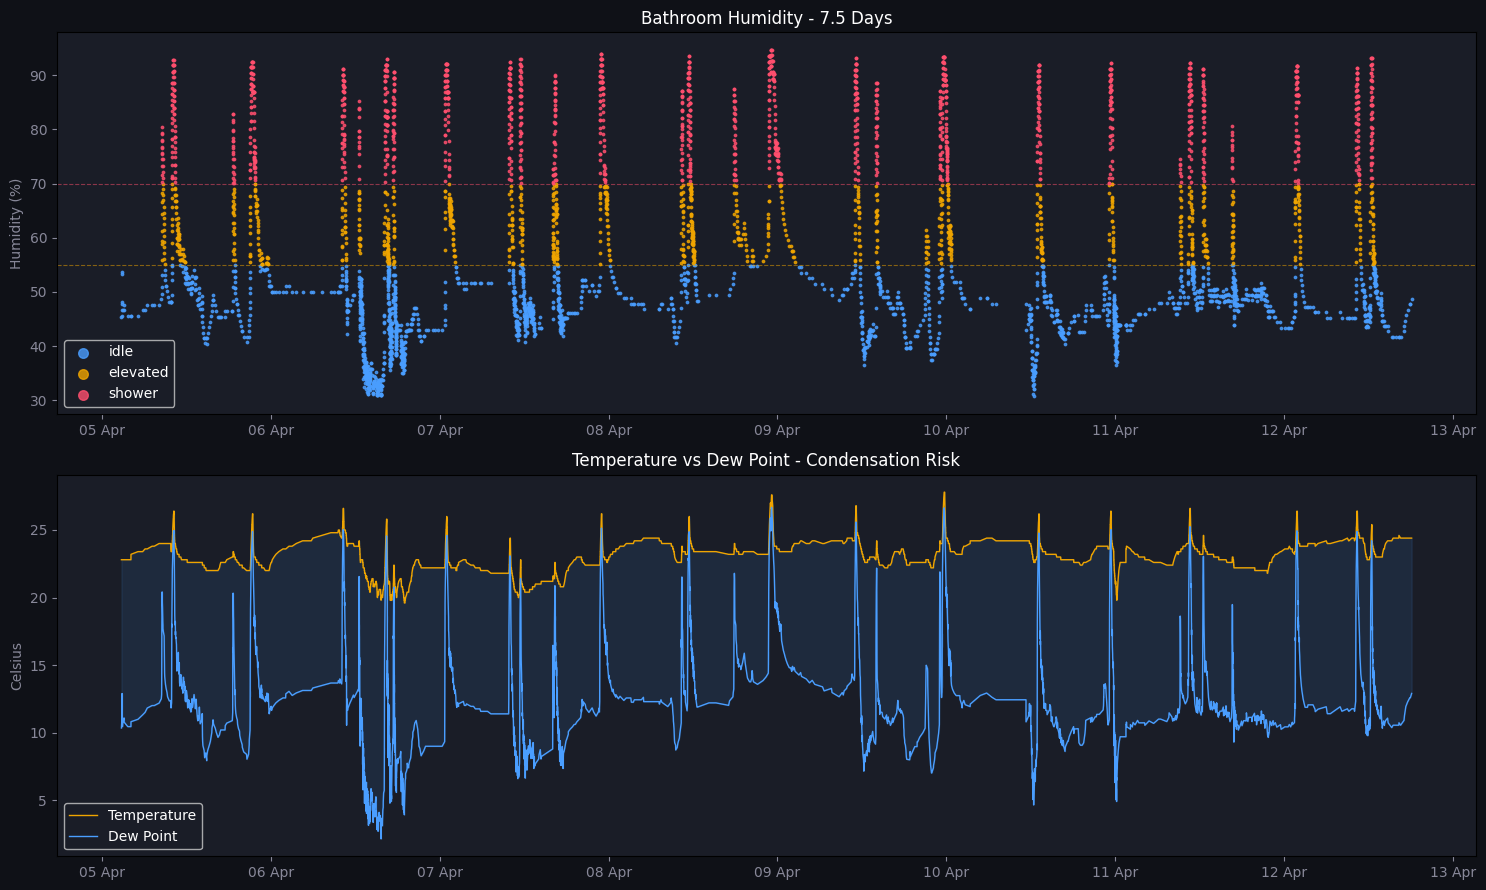

In [55]:
import os
os.makedirs('images', exist_ok=True)

colors = {'idle': '#4a9eff', 'elevated': '#f0a500', 'shower': '#ff4f6e'}
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

for event, color in colors.items():
    mask = df['event'] == event
    axes[0].scatter(df.loc[mask, 'local_time'], df.loc[mask, 'humidity'],
                    c=color, s=3, label=event, alpha=0.8)
axes[0].axhline(70, color='#ff4f6e', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(55, color='#f0a500', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_ylabel('Humidity (%)')
axes[0].set_title('Bathroom Humidity - 7.5 Days', color='white')
axes[0].legend(markerscale=4, facecolor='#1a1d27', labelcolor='white')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[0].xaxis.set_major_locator(mdates.DayLocator())

axes[1].plot(df['local_time'], df['temperature'], color='#f0a500', linewidth=1, label='Temperature')
axes[1].plot(df['local_time'], df['dew_point'], color='#4a9eff', linewidth=1, label='Dew Point')
axes[1].fill_between(df['local_time'], df['dew_point'], df['temperature'],
                     where=df['temperature'] > df['dew_point'], alpha=0.1, color='#4a9eff')
axes[1].set_ylabel('Celsius')
axes[1].set_title('Temperature vs Dew Point - Condensation Risk', color='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.savefig('images/humid_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 5. Linear Regression — predicting dew point

Dew point is mathematically derivable from temperature and humidity, so R² near 1.0 here is **expected, not a meaningful result**. The value of doing this was learning how to split data, fit a model, and evaluate it — not discovering new patterns.

In [56]:
X = df[['humidity', 'temperature']].values
y = df['dew_point'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R2:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f} C")
print(f"Coefficients: humidity={model.coef_[0]:.4f}, temperature={model.coef_[1]:.4f}")
print("\nNote: R2 near 1.0 is expected here, not impressive.")
print("Dew point is mathematically derived from these inputs.")

R2:  0.9922
MAE: 0.375 C
Coefficients: humidity=0.2525, temperature=0.9603

Note: R2 near 1.0 is expected here, not impressive.
Dew point is mathematically derived from these inputs.
